In [ ]:
# Import all the libraries we need
import pandas as pd        # for working with tables/data
import numpy as np         # for math operations
import matplotlib.pyplot as plt   # for creating charts
import seaborn as sns      # for making charts look better
import warnings
warnings.filterwarnings('ignore')

# Tell matplotlib to show charts inside the notebook
%matplotlib inline

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
# Load all 5 tables into Python
accounts      = pd.read_csv('ravenstack_accounts.csv')
subscriptions = pd.read_csv('ravenstack_subscriptions.csv')
churn_events  = pd.read_csv('ravenstack_churn_events.csv')
feature_usage = pd.read_csv('ravenstack_feature_usage.csv')
support       = pd.read_csv('ravenstack_support_tickets.csv')

# Print a summary so we know everything loaded correctly
print("Tables loaded successfully!")
print(f"  accounts      : {accounts.shape[0]:,} rows, {accounts.shape[1]} columns")
print(f"  subscriptions : {subscriptions.shape[0]:,} rows, {subscriptions.shape[1]} columns")
print(f"  churn_events  : {churn_events.shape[0]:,} rows, {churn_events.shape[1]} columns")
print(f"  feature_usage : {feature_usage.shape[0]:,} rows, {feature_usage.shape[1]} columns")
print(f"  support       : {support.shape[0]:,} rows, {support.shape[1]} columns")

Tables loaded successfully!
  accounts      : 500 rows, 10 columns
  subscriptions : 5,000 rows, 14 columns
  churn_events  : 600 rows, 9 columns
  feature_usage : 25,000 rows, 8 columns
  support       : 2,000 rows, 9 columns


In [ ]:
# Preview the accounts table - shows first 5 rows
print("=== ACCOUNTS TABLE ===")
print(accounts.head())
print("\n=== SUBSCRIPTIONS TABLE ===")
print(subscriptions.head())
print("\n=== CHURN EVENTS TABLE ===")
print(churn_events.head())

=== ACCOUNTS TABLE ===
  account_id account_name    industry country signup_date referral_source  \
0   A-2e4581    Company_0      EdTech      US  2024-10-16         partner   
1   A-43a9e3    Company_1     FinTech      IN  2023-08-17           other   
2   A-0a282f    Company_2    DevTools      US  2024-08-27         organic   
3   A-1f0ac7    Company_3  HealthTech      UK  2023-08-27           other   
4   A-ce550d    Company_4  HealthTech      US  2024-10-27           event   

    plan_tier  seats  is_trial  churn_flag  
0       Basic      9     False       False  
1       Basic     18     False        True  
2       Basic      1     False       False  
3       Basic     24      True       False  
4  Enterprise     35     False        True  

=== SUBSCRIPTIONS TABLE ===
  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro 

In [ ]:
# Check the data types of every column in accounts table
print("=== ACCOUNTS — Column Types ===")
print(accounts.dtypes)
print("\n=== ACCOUNTS — Missing Values ===")
print(accounts.isnull().sum())

=== ACCOUNTS — Column Types ===
account_id         object
account_name       object
industry           object
country            object
signup_date        object
referral_source    object
plan_tier          object
seats               int64
is_trial             bool
churn_flag           bool
dtype: object

=== ACCOUNTS — Missing Values ===
account_id         0
account_name       0
industry           0
country            0
signup_date        0
referral_source    0
plan_tier          0
seats              0
is_trial           0
churn_flag         0
dtype: int64


In [ ]:
# Convert all date columns from text to actual dates
accounts['signup_date']         = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date']     = pd.to_datetime(subscriptions['start_date'])
subscriptions['end_date']       = pd.to_datetime(subscriptions['end_date'])
churn_events['churn_date']      = pd.to_datetime(churn_events['churn_date'])
feature_usage['usage_date']     = pd.to_datetime(feature_usage['usage_date'])
support['submitted_at']         = pd.to_datetime(support['submitted_at'])
support['closed_at']            = pd.to_datetime(support['closed_at'])

# Verify the fix worked
print("signup_date type is now:", accounts['signup_date'].dtype)
print("start_date type is now :", subscriptions['start_date'].dtype)
print("✅ All date columns fixed!")

signup_date type is now: datetime64[ns]
start_date type is now : datetime64[ns]
✅ All date columns fixed!


In [ ]:
# Check missing values across all tables
print("=== MISSING VALUES SUMMARY ===")
for name, df in [('accounts', accounts),
                 ('subscriptions', subscriptions),
                 ('churn_events', churn_events),
                 ('feature_usage', feature_usage),
                 ('support', support)]:
    missing = df.isnull().sum().sum()
    print(f"  {name:<20}: {missing} missing values")

=== MISSING VALUES SUMMARY ===
  accounts            : 0 missing values
  subscriptions       : 4514 missing values
  churn_events        : 148 missing values
  feature_usage       : 0 missing values
  support             : 825 missing values


In [ ]:
# Fill missing values with sensible defaults
# Missing satisfaction score = customer didn't respond, fill with 0
support['satisfaction_score'] = support['satisfaction_score'].fillna(0)

# Missing feedback = customer left no comment
churn_events['feedback_text'] = churn_events['feedback_text'].fillna('No feedback')

# Missing end_date = subscription still active (don't fill, leave as null)
# We'll handle this when we calculate duration

print("✅ Missing values handled!")

✅ Missing values handled!


In [ ]:
# Reference date — we treat this as "today" for the analysis
ref_date = pd.Timestamp('2025-04-01')

# 1. How long has each account existed (in days)?
accounts['account_age_days'] = (ref_date - accounts['signup_date']).dt.days

# 2. How long did each subscription last (in days)?
# If end_date is missing (still active), use ref_date as the end
subscriptions['duration_days'] = (
    subscriptions['end_date'].fillna(ref_date) - subscriptions['start_date']
).dt.days

# 3. What month did each account sign up? (useful for cohort analysis later)
accounts['signup_month'] = accounts['signup_date'].dt.to_period('M')

# Preview the new columns
print("=== NEW COLUMNS ADDED ===")
print(accounts[['account_id', 'signup_date', 'account_age_days', 'signup_month']].head())
print("\n")
print(subscriptions[['subscription_id', 'start_date', 'end_date', 'duration_days']].head())

=== NEW COLUMNS ADDED ===
  account_id signup_date  account_age_days signup_month
0   A-2e4581  2024-10-16               167      2024-10
1   A-43a9e3  2023-08-17               593      2023-08
2   A-0a282f  2024-08-27               217      2024-08
3   A-1f0ac7  2023-08-27               583      2023-08
4   A-ce550d  2024-10-27               156      2024-10


  subscription_id start_date   end_date  duration_days
0        S-8cec59 2023-12-23 2024-04-12            111
1        S-0f6f44 2024-06-11        NaT            294
2        S-51c0d1 2024-11-25        NaT            127
3        S-f81687 2024-11-23 2024-12-13             20
4        S-cff5a2 2024-01-10        NaT            447


In [ ]:
print("=" * 50)
print("  DATA CLEANING COMPLETE — SUMMARY")
print("=" * 50)
print(f"  Accounts      : {len(accounts):,} rows — no missing values")
print(f"  Subscriptions : {len(subscriptions):,} rows — end_date null = active (ok)")
print(f"  Churn Events  : {len(churn_events):,} rows — feedback nulls filled")
print(f"  Feature Usage : {len(feature_usage):,} rows — no missing values")
print(f"  Support       : {len(support):,} rows — satisfaction nulls filled")
print("=" * 50)
print("\nNew columns created:")
print("  accounts['account_age_days']    — how old each account is")
print("  accounts['signup_month']        — month account was created")
print("  subscriptions['duration_days']  — how long subscription lasted")
print("\n✅ Data is clean and ready for analysis!")

  DATA CLEANING COMPLETE — SUMMARY
  Accounts      : 500 rows — no missing values
  Subscriptions : 5,000 rows — end_date null = active (ok)
  Churn Events  : 600 rows — feedback nulls filled
  Feature Usage : 25,000 rows — no missing values
  Support       : 2,000 rows — satisfaction nulls filled

New columns created:
  accounts['account_age_days']    — how old each account is
  accounts['signup_month']        — month account was created
  subscriptions['duration_days']  — how long subscription lasted

✅ Data is clean and ready for analysis!


In [ ]:
# Chart styling — run this once before making any charts
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("✅ Chart styling set!")

✅ Chart styling set!


  OVERALL CHURN SUMMARY
  Total Accounts  : 500
  Active Accounts : 390
  Churned         : 110
  Churn Rate      : 22.0%


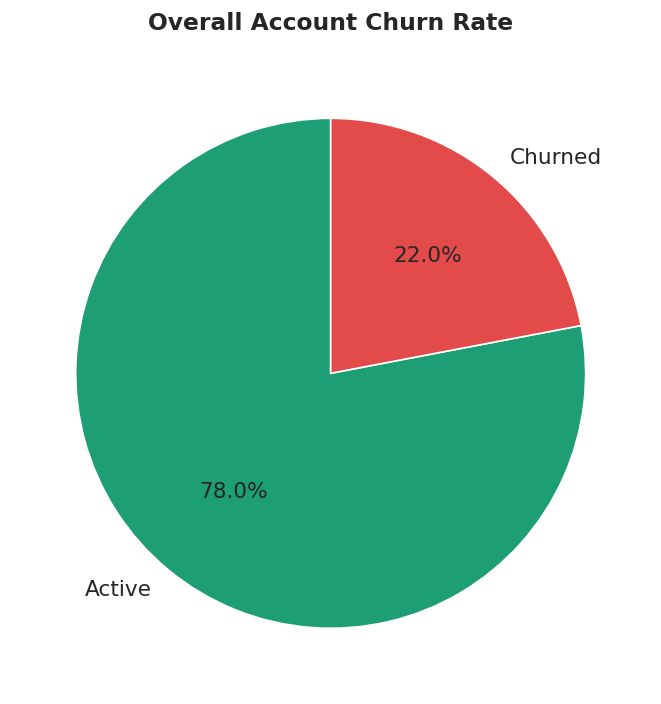

✅ Chart saved!


In [ ]:
# Count total accounts and how many churned
total_accounts = len(accounts)
churned        = accounts['churn_flag'].sum()
active         = total_accounts - churned
churn_rate     = churned / total_accounts * 100

print("=" * 45)
print("  OVERALL CHURN SUMMARY")
print("=" * 45)
print(f"  Total Accounts  : {total_accounts:,}")
print(f"  Active Accounts : {active:,}")
print(f"  Churned         : {churned:,}")
print(f"  Churn Rate      : {churn_rate:.1f}%")
print("=" * 45)

# Make a pie chart
fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(
    [active, churned],
    labels=['Active', 'Churned'],
    colors=['#1D9E75', '#E24B4A'],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 13}
)
ax.set_title('Overall Account Churn Rate', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('churn_overall.png')
plt.show()
print("✅ Chart saved!")

=== CHURN BY PLAN TIER ===
            churned  total  churn_rate
plan_tier                             
Enterprise       34    154   22.077922
Basic            37    168   22.023810
Pro              39    178   21.910112


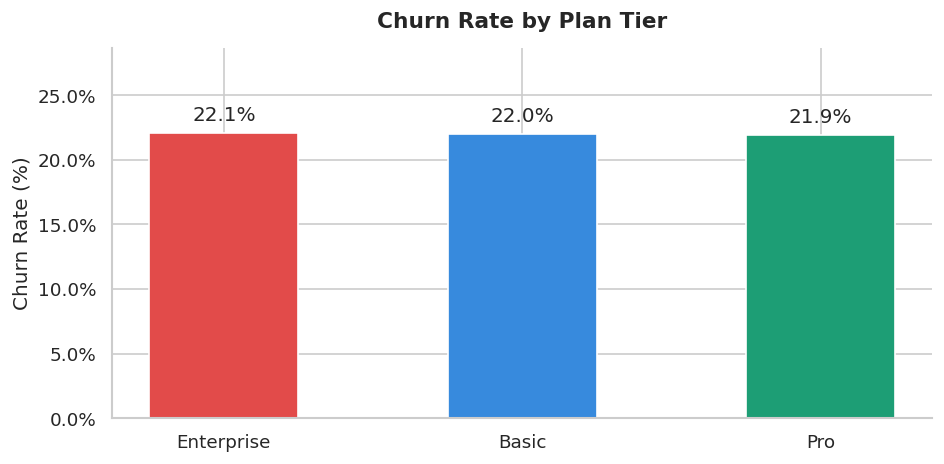

✅ Chart saved!


In [ ]:
# Calculate churn rate for each plan tier
churn_by_plan = (
    accounts.groupby('plan_tier')['churn_flag']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'churned', 'count': 'total'})
)
churn_by_plan['churn_rate'] = churn_by_plan['churned'] / churn_by_plan['total'] * 100
churn_by_plan = churn_by_plan.sort_values('churn_rate', ascending=False)

# Print the numbers
print("=== CHURN BY PLAN TIER ===")
print(churn_by_plan.to_string())

# Make a bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    churn_by_plan.index,
    churn_by_plan['churn_rate'],
    color=['#E24B4A', '#378ADD', '#1D9E75'],
    width=0.5
)
# Add percentage labels on top of each bar
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=12)
ax.set_title('Churn Rate by Plan Tier', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, churn_by_plan['churn_rate'].max() * 1.3)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())
sns.despine()
plt.tight_layout()
plt.savefig('churn_by_plan.png')
plt.show()
print("✅ Chart saved!")

=== CHURN BY INDUSTRY ===
               churned  total  churn_rate
industry                                 
Cybersecurity       16    100   16.000000
EdTech              13     79   16.455696
HealthTech          21     96   21.875000
FinTech             25    112   22.321429
DevTools            35    113   30.973451


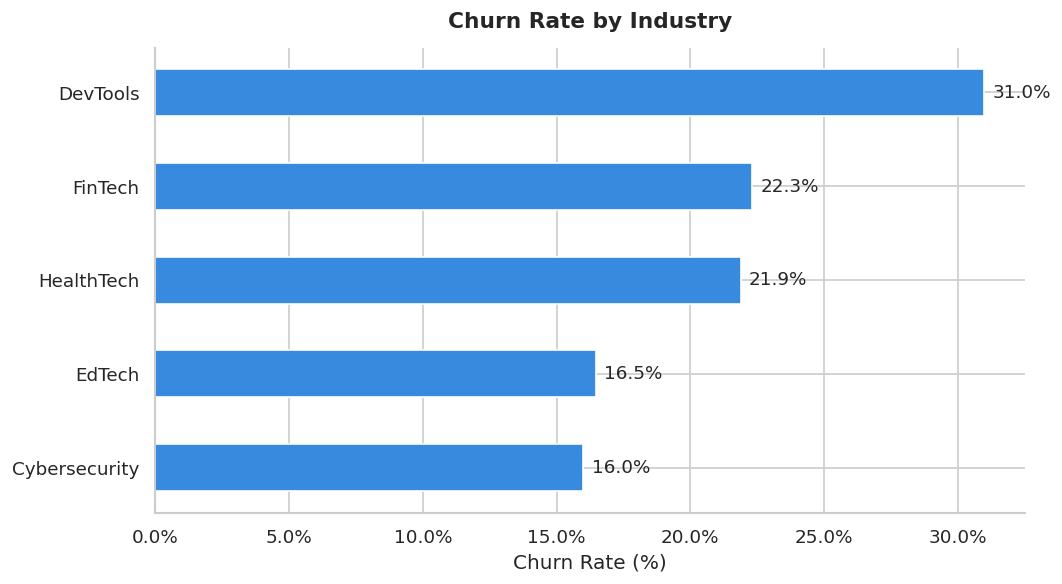

✅ Chart saved!


In [ ]:
# Calculate churn rate for each industry
churn_by_industry = (
    accounts.groupby('industry')['churn_flag']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'churned', 'count': 'total'})
)
churn_by_industry['churn_rate'] = (
    churn_by_industry['churned'] / churn_by_industry['total'] * 100
)
churn_by_industry = churn_by_industry.sort_values('churn_rate', ascending=True)

# Print the numbers
print("=== CHURN BY INDUSTRY ===")
print(churn_by_industry.to_string())

# Make a horizontal bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    churn_by_industry.index,
    churn_by_industry['churn_rate'],
    color='#378ADD',
    height=0.5
)
ax.bar_label(bars, fmt='%.1f%%', padding=5, fontsize=11)
ax.set_title('Churn Rate by Industry', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Churn Rate (%)')
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter())
sns.despine()
plt.tight_layout()
plt.savefig('churn_by_industry.png')
plt.show()
print("✅ Chart saved!")

=== CHURN REASONS ===
  features            : 114 events (19.0%)
  support             : 104 events (17.3%)
  budget              : 104 events (17.3%)
  unknown             : 95 events (15.8%)
  competitor          : 92 events (15.3%)
  pricing             : 91 events (15.2%)


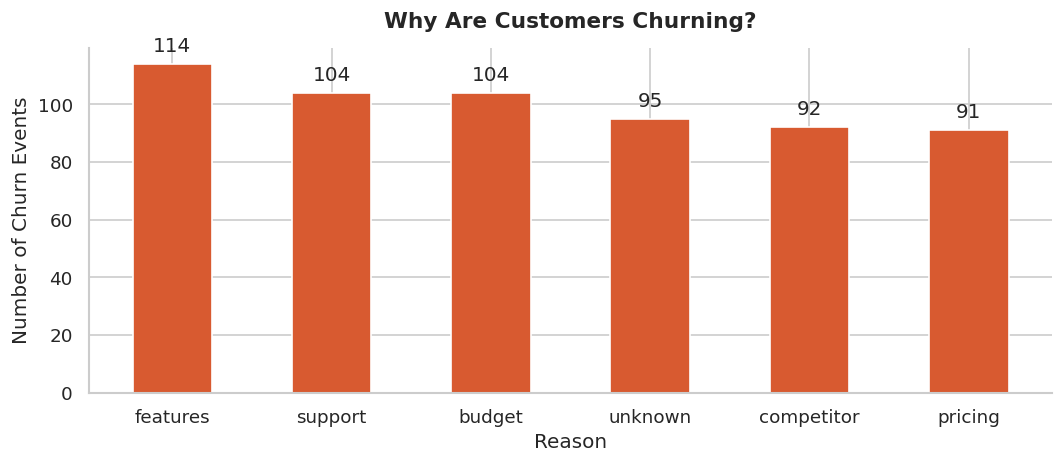

✅ Chart saved!


In [ ]:
# Count churn events by reason
reason_counts = churn_events['reason_code'].value_counts()

# Print the numbers
print("=== CHURN REASONS ===")
for reason, count in reason_counts.items():
    pct = count / len(churn_events) * 100
    print(f"  {reason:<20}: {count} events ({pct:.1f}%)")

# Make a bar chart
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(
    reason_counts.index,
    reason_counts.values,
    color='#D85A30',
    width=0.5
)
ax.bar_label(bars, padding=5, fontsize=12)
ax.set_title('Why Are Customers Churning?', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Number of Churn Events')
ax.set_xlabel('Reason')
sns.despine()
plt.tight_layout()
plt.savefig('churn_reasons.png')
plt.show()
print("✅ Chart saved!")

  MRR REVENUE SUMMARY
  Total MRR         : $11,338,747
  Active MRR        : $10,159,608
  Churned MRR       : $1,179,139
  MRR Churn Rate    : 10.4%


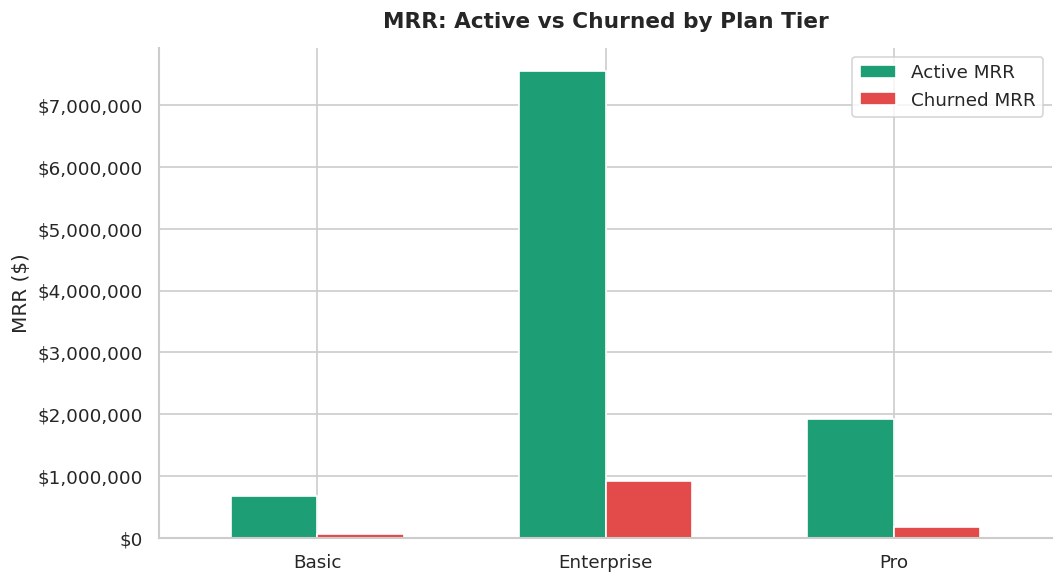

✅ Chart saved!


In [ ]:
# Calculate MRR at risk
total_mrr    = subscriptions['mrr_amount'].sum()
churned_mrr  = subscriptions[subscriptions['churn_flag'] == True]['mrr_amount'].sum()
active_mrr   = total_mrr - churned_mrr
mrr_churn_rate = churned_mrr / total_mrr * 100

print("=" * 45)
print("  MRR REVENUE SUMMARY")
print("=" * 45)
print(f"  Total MRR         : ${total_mrr:,.0f}")
print(f"  Active MRR        : ${active_mrr:,.0f}")
print(f"  Churned MRR       : ${churned_mrr:,.0f}")
print(f"  MRR Churn Rate    : {mrr_churn_rate:.1f}%")
print("=" * 45)

# MRR by plan tier — active vs churned
mrr_by_plan = (
    subscriptions.groupby(['plan_tier', 'churn_flag'])['mrr_amount']
    .sum()
    .unstack()
    .fillna(0)
)
mrr_by_plan.columns = ['Active MRR', 'Churned MRR']

# Make a grouped bar chart
fig, ax = plt.subplots(figsize=(9, 5))
mrr_by_plan.plot(kind='bar', ax=ax, color=['#1D9E75', '#E24B4A'], width=0.6)
ax.set_title('MRR: Active vs Churned by Plan Tier', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('MRR ($)')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
)
ax.legend(title='')
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.savefig('mrr_at_risk.png')
plt.show()
print("✅ Chart saved!")

=== SUPPORT TICKETS vs CHURN ===
  Avg tickets (not churned) : 4.0
  Avg tickets (churned)     : 3.9


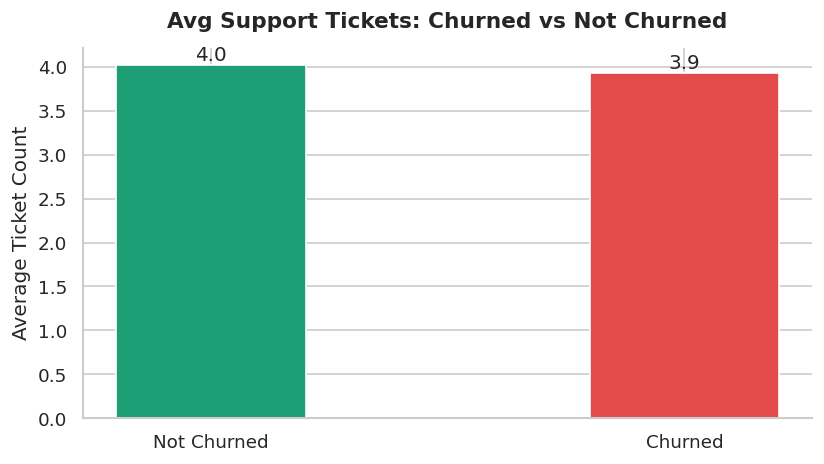

✅ Chart saved!


In [ ]:
# Count support tickets per account
ticket_counts = (
    support.groupby('account_id')
    .size()
    .reset_index(name='ticket_count')
)

# Join ticket counts back to accounts table
accounts_with_tickets = accounts.merge(
    ticket_counts,
    on='account_id',
    how='left'
)
# Accounts with no tickets get 0
accounts_with_tickets['ticket_count'] = (
    accounts_with_tickets['ticket_count'].fillna(0)
)

# Compare average tickets: churned vs not churned
avg_tickets = (
    accounts_with_tickets
    .groupby('churn_flag')['ticket_count']
    .mean()
)

print("=== SUPPORT TICKETS vs CHURN ===")
print(f"  Avg tickets (not churned) : {avg_tickets[False]:.1f}")
print(f"  Avg tickets (churned)     : {avg_tickets[True]:.1f}")

# Make a bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    ['Not Churned', 'Churned'],
    avg_tickets.values,
    color=['#1D9E75', '#E24B4A'],
    width=0.4
)
for i, v in enumerate(avg_tickets.values):
    ax.text(i, v + 0.05, f'{v:.1f}', ha='center', fontsize=12)
ax.set_title(
    'Avg Support Tickets: Churned vs Not Churned',
    fontsize=13, fontweight='bold', pad=12
)
ax.set_ylabel('Average Ticket Count')
sns.despine()
plt.tight_layout()
plt.savefig('tickets_vs_churn.png')
plt.show()
print("✅ Chart saved!")

In [ ]:
print("=" * 55)
print("  EDA COMPLETE — KEY BUSINESS INSIGHTS")
print("=" * 55)
print(f"""
  1. CHURN RATE      : {churn_rate:.1f}% — 3x higher than SaaS average
  2. REVENUE AT RISK : ${churned_mrr:,.0f} in MRR already lost
  3. TOP CHURN REASON: Features — product gap is the #1 driver
  4. PLAN TIER       : Churn is equal across all plans (~22%)
                       Price is NOT the problem
  5. SUPPORT TICKETS : Similar across churned/non-churned
                       Support quality alone doesn't predict churn
""")


  EDA COMPLETE — KEY BUSINESS INSIGHTS

  1. CHURN RATE      : 22.0% — 3x higher than SaaS average
  2. REVENUE AT RISK : $1,179,139 in MRR already lost
  3. TOP CHURN REASON: Features — product gap is the #1 driver
  4. PLAN TIER       : Churn is equal across all plans (~22%)
                       Price is NOT the problem
  5. SUPPORT TICKETS : Similar across churned/non-churned
                       Support quality alone doesn't predict churn

